In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)

In [4]:
X_train = torch.randn(1000, 784)

In [5]:
X_train

tensor([[ 4.4084e-01,  9.2301e-02,  1.0812e+00,  ..., -1.1256e+00,
          7.3481e-02,  6.5349e-01],
        [ 8.0608e-01, -3.9319e-01, -7.5958e-01,  ..., -2.9229e-01,
         -2.8397e-01, -1.4452e-01],
        [ 3.2669e-01, -4.4860e-01,  1.6757e+00,  ...,  6.9160e-01,
          1.6751e+00, -2.1172e-01],
        ...,
        [ 1.7253e+00,  4.7596e-01,  1.0284e+00,  ..., -2.0400e+00,
          7.4710e-01, -1.2832e+00],
        [ 9.0141e-01,  1.4714e+00, -8.5221e-01,  ...,  1.8157e+00,
         -1.3180e+00,  1.1157e-01],
        [-7.9933e-01, -2.2170e+00,  6.5055e-01,  ...,  1.6153e-03,
         -1.2027e+00,  1.2663e+00]])

In [6]:
y_train = torch.randint(0, 10, (1000, ))
y_train

tensor([5, 6, 9, 1, 1, 2, 9, 6, 9, 2, 6, 8, 2, 5, 1, 4, 2, 7, 1, 2, 2, 5, 7, 2,
        4, 9, 3, 4, 7, 3, 9, 1, 7, 2, 2, 0, 9, 4, 5, 8, 2, 3, 6, 2, 8, 9, 6, 7,
        8, 6, 5, 7, 6, 7, 8, 7, 2, 3, 6, 9, 2, 1, 7, 0, 6, 5, 5, 7, 8, 8, 3, 5,
        5, 7, 5, 8, 5, 3, 2, 1, 1, 2, 2, 5, 4, 1, 7, 5, 0, 7, 4, 9, 6, 5, 6, 8,
        0, 3, 5, 5, 4, 1, 1, 9, 9, 4, 0, 4, 0, 2, 9, 6, 9, 2, 7, 8, 4, 3, 9, 5,
        9, 6, 5, 7, 6, 9, 8, 1, 9, 5, 4, 5, 4, 0, 8, 4, 7, 3, 2, 5, 6, 1, 1, 1,
        6, 4, 6, 9, 1, 9, 3, 3, 1, 4, 2, 8, 5, 1, 0, 0, 6, 0, 6, 8, 7, 2, 5, 6,
        9, 1, 3, 9, 3, 1, 1, 5, 5, 8, 9, 8, 9, 1, 9, 5, 4, 0, 8, 7, 5, 2, 8, 7,
        1, 9, 1, 9, 2, 9, 6, 9, 1, 1, 7, 0, 7, 4, 3, 9, 8, 8, 7, 1, 7, 3, 4, 3,
        5, 2, 3, 0, 7, 5, 6, 9, 5, 4, 9, 3, 7, 7, 8, 7, 0, 2, 2, 5, 4, 9, 7, 5,
        7, 1, 5, 4, 0, 5, 7, 6, 8, 5, 6, 3, 4, 0, 9, 1, 4, 0, 1, 3, 4, 3, 0, 1,
        8, 4, 3, 1, 6, 3, 7, 5, 5, 7, 2, 3, 2, 7, 5, 4, 1, 9, 2, 4, 1, 0, 6, 1,
        6, 5, 3, 9, 3, 8, 3, 5, 3, 4, 4,

In [7]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

In [8]:
X_test = torch.randn(200, 784)
y_test = torch.randint(0, 10, (200, ))

In [9]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [10]:
train_losses = []
test_accuracies = []

In [11]:
for epoch in range(20):
    model.train()
    total_loss = 0
    # 记录训练批次总数
    batch_num = len(train_loader)

    for bx, by in train_loader:
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

     # 用批次总数求平均loss
    avg_train_loss = total_loss / batch_num
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_test), dim=1)
        acc = (preds == y_test).float().mean().item()

    test_accuracies.append(acc)

    # 打印训练信息
    print(f"Epoch [{epoch+1}/20] | Train Loss: {avg_train_loss:.4f} | Test Acc: {acc:.4f}")

Epoch [1/20] | Train Loss: 2.3447 | Test Acc: 0.1150
Epoch [2/20] | Train Loss: 1.7015 | Test Acc: 0.1100
Epoch [3/20] | Train Loss: 1.2048 | Test Acc: 0.1150
Epoch [4/20] | Train Loss: 0.7283 | Test Acc: 0.1100
Epoch [5/20] | Train Loss: 0.3743 | Test Acc: 0.1200
Epoch [6/20] | Train Loss: 0.1828 | Test Acc: 0.1250
Epoch [7/20] | Train Loss: 0.1007 | Test Acc: 0.1250
Epoch [8/20] | Train Loss: 0.0639 | Test Acc: 0.1300
Epoch [9/20] | Train Loss: 0.0453 | Test Acc: 0.1350
Epoch [10/20] | Train Loss: 0.0347 | Test Acc: 0.1300
Epoch [11/20] | Train Loss: 0.0276 | Test Acc: 0.1350
Epoch [12/20] | Train Loss: 0.0227 | Test Acc: 0.1350
Epoch [13/20] | Train Loss: 0.0191 | Test Acc: 0.1350
Epoch [14/20] | Train Loss: 0.0163 | Test Acc: 0.1350
Epoch [15/20] | Train Loss: 0.0142 | Test Acc: 0.1300
Epoch [16/20] | Train Loss: 0.0125 | Test Acc: 0.1300
Epoch [17/20] | Train Loss: 0.0110 | Test Acc: 0.1300
Epoch [18/20] | Train Loss: 0.0099 | Test Acc: 0.1300
Epoch [19/20] | Train Loss: 0.0089 | 

In [12]:
train_losses

[2.344741851091385,
 1.7014783769845963,
 1.2047685086727142,
 0.7282729372382164,
 0.37425913102924824,
 0.18275090586394072,
 0.10074944561347365,
 0.06390211824327707,
 0.045254592318087816,
 0.034679487347602844,
 0.027642297907732427,
 0.02270125481300056,
 0.01908386091236025,
 0.016335560765583068,
 0.014171603368595243,
 0.012450104753952473,
 0.01104045903775841,
 0.009896916977595538,
 0.008891724864952266,
 0.008058704494033009]

In [13]:
test_accuracies

[0.11500000208616257,
 0.10999999940395355,
 0.11500000208616257,
 0.10999999940395355,
 0.11999999731779099,
 0.125,
 0.125,
 0.12999999523162842,
 0.13500000536441803,
 0.12999999523162842,
 0.13500000536441803,
 0.13500000536441803,
 0.13500000536441803,
 0.13500000536441803,
 0.12999999523162842,
 0.12999999523162842,
 0.12999999523162842,
 0.12999999523162842,
 0.12999999523162842,
 0.12999999523162842]

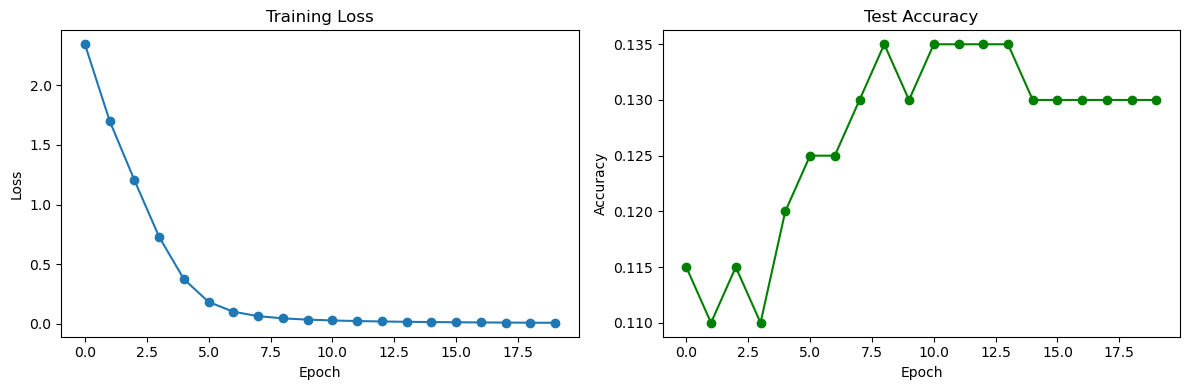

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(test_accuracies, marker='o', color='green')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()